# Financial Forecasting & Variance Analysis
**Tools:** Python, Pandas, NumPy, Matplotlib, Scikit-learn, Seaborn  
**Summary:** End-to-end pipeline that generates financial data, runs variance analysis to flag anomalies, trains an ML forecasting model, and produces a full set of dashboards.

---


## 1. Imports & Setup

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import mean_absolute_percentage_error

%matplotlib inline

OUTPUT_DIR = Path("output")
OUTPUT_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "font.family":       "DejaVu Sans",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "grid.linestyle":    "--",
    "figure.dpi":        130,
})

PALETTE = {
    "actual":   "#2563EB",
    "budget":   "#9CA3AF",
    "forecast": "#F59E0B",
    "positive": "#10B981",
    "negative": "#EF4444",
}

print("Setup complete.")


Setup complete.


## 2. Data Generation
Simulates **24 months of actuals** and **12 months of budget** across 4 departments (Sales, Marketing, Operations, R&D).  
Actuals include realistic noise and random one-off shocks to mimic real-world variance.


In [3]:
np.random.seed(42)

DEPARTMENTS = ["Sales", "Marketing", "Operations", "R&D"]

REVENUE_BASE = {"Sales": 500_000, "Marketing": 80_000, "Operations": 200_000, "R&D": 50_000}
COST_BASE    = {"Sales": 320_000, "Marketing": 70_000, "Operations": 160_000, "R&D": 45_000}

SEASONALITY = np.array([
    0.85, 0.88, 0.95, 1.00, 1.05, 1.10,
    1.08, 1.03, 1.07, 1.12, 1.15, 1.20,
])

def generate_data(start_year=2023, actuals_months=24):
    records = []
    total_months = actuals_months + 12

    for dept in DEPARTMENTS:
        rev_base  = REVENUE_BASE[dept]
        cost_base = COST_BASE[dept]

        for i in range(total_months):
            year   = start_year + (i // 12)
            month  = (i % 12) + 1
            date   = pd.Timestamp(year=year, month=month, day=1)
            season = SEASONALITY[month - 1]
            growth = 1 + 0.005 * i

            budget_rev  = rev_base  * season * growth
            budget_cost = cost_base * season * growth * np.random.uniform(0.98, 1.02)

            is_actual = i < actuals_months
            if is_actual:
                noise_rev  = np.random.normal(1.0, 0.04)
                noise_cost = np.random.normal(1.0, 0.03)
                shock_rev  = 1.15 if np.random.random() < 0.08 else 1.0
                shock_cost = 1.12 if np.random.random() < 0.06 else 1.0
                actual_rev  = budget_rev  * noise_rev  * shock_rev
                actual_cost = budget_cost * noise_cost * shock_cost
            else:
                actual_rev = actual_cost = None

            records.append({
                "date": date, "year": year, "month": month, "department": dept,
                "budget_revenue": round(budget_rev, 2),
                "budget_cost":    round(budget_cost, 2),
                "actual_revenue": round(actual_rev, 2)  if actual_rev  else None,
                "actual_cost":    round(actual_cost, 2) if actual_cost else None,
                "is_actual":      is_actual,
            })

    df = pd.DataFrame(records)
    df["budget_profit"] = df["budget_revenue"] - df["budget_cost"]
    df["actual_profit"] = df["actual_revenue"] - df["actual_cost"]
    return df

df = generate_data()
df.to_csv(OUTPUT_DIR / "financial_data.csv", index=False)
print(f"Generated {len(df)} rows | {df['department'].nunique()} departments | {df[df['is_actual']]['date'].nunique()} actual months")
df[df["is_actual"]].head(8)


Generated 144 rows | 4 departments | 24 actual months


,date,year,month,department,budget_revenue,budget_cost,actual_revenue,actual_cost,is_actual,budget_profit,actual_profit
0,2023-01-01,2023,1,Sales,425000.0,270635.00,406098.04,306011.08,True,154365.00,100086.96
1,2023-02-01,2023,2,Sales,442200.0,287153.23,540653.08,293764.37,True,155046.77,246888.71
2,2023-03-01,2023,3,Sales,479750.0,311122.93,468602.95,306221.16,True,168627.07,162381.79
3,2023-04-01,2023,4,Sales,507500.0,325121.64,472484.17,319637.28,True,182378.36,152846.89
4,2023-05-01,2023,5,Sales,535500.0,339870.55,520434.38,318054.73,True,195629.45,202379.65
5,2023-06-01,2023,6,Sales,563750.0,361005.43,551474.17,362206.74,True,202744.57,189267.43
6,2023-07-01,2023,7,Sales,556200.0,349774.89,542845.55,359716.61,True,206425.11,183128.94
7,2023-08-01,2023,8,Sales,533025.0,340319.35,612647.81,329520.57,True,192705.65,283127.24


## 3. Variance Analysis
Computes revenue, cost, and profit variance against budget.  
Flags any month/department combination exceeding **±5% deviation** as a significant anomaly.


In [4]:
VARIANCE_THRESHOLD = 0.05

def compute_variance(df):
    actuals = df[df["is_actual"]].copy()
    actuals["rev_variance_abs"]    = actuals["actual_revenue"] - actuals["budget_revenue"]
    actuals["rev_variance_pct"]    = actuals["rev_variance_abs"] / actuals["budget_revenue"]
    actuals["cost_variance_abs"]   = actuals["actual_cost"] - actuals["budget_cost"]
    actuals["cost_variance_pct"]   = actuals["cost_variance_abs"] / actuals["budget_cost"]
    actuals["profit_variance_abs"] = actuals["actual_profit"] - actuals["budget_profit"]
    actuals["profit_variance_pct"] = actuals["profit_variance_abs"] / actuals["budget_profit"].abs()
    actuals["rev_flag"]    = actuals["rev_variance_pct"].abs()    > VARIANCE_THRESHOLD
    actuals["cost_flag"]   = actuals["cost_variance_pct"].abs()   > VARIANCE_THRESHOLD
    actuals["profit_flag"] = actuals["profit_variance_pct"].abs() > VARIANCE_THRESHOLD
    return actuals

def summarize_by_department(variance_df):
    summary = variance_df.groupby("department").agg(
        total_budget_revenue = ("budget_revenue", "sum"),
        total_actual_revenue = ("actual_revenue", "sum"),
        total_budget_cost    = ("budget_cost",    "sum"),
        total_actual_cost    = ("actual_cost",    "sum"),
        total_budget_profit  = ("budget_profit",  "sum"),
        total_actual_profit  = ("actual_profit",  "sum"),
        rev_variance_abs     = ("rev_variance_abs",  "sum"),
        cost_variance_abs    = ("cost_variance_abs", "sum"),
        flagged_rev_months   = ("rev_flag",  "sum"),
        flagged_cost_months  = ("cost_flag", "sum"),
    ).reset_index()
    summary["rev_variance_pct"]    = summary["rev_variance_abs"]  / summary["total_budget_revenue"]
    summary["cost_variance_pct"]   = summary["cost_variance_abs"] / summary["total_budget_cost"]
    summary["profit_variance_abs"] = summary["total_actual_profit"] - summary["total_budget_profit"]
    summary["profit_variance_pct"] = summary["profit_variance_abs"] / summary["total_budget_profit"].abs()
    return summary

def identify_drivers(variance_df, top_n=5):
    v = variance_df.copy()
    v["period_label"] = v["date"].dt.strftime("%b %Y") + " — " + v["department"]
    return {
        "top_revenue_beats":  v.nlargest(top_n,  "rev_variance_abs")[["period_label","rev_variance_abs","rev_variance_pct"]].rename(columns={"rev_variance_abs":"variance_abs","rev_variance_pct":"variance_pct"}),
        "top_revenue_misses": v.nsmallest(top_n, "rev_variance_abs")[["period_label","rev_variance_abs","rev_variance_pct"]].rename(columns={"rev_variance_abs":"variance_abs","rev_variance_pct":"variance_pct"}),
        "top_cost_overruns":  v.nlargest(top_n,  "cost_variance_abs")[["period_label","cost_variance_abs","cost_variance_pct"]].rename(columns={"cost_variance_abs":"variance_abs","cost_variance_pct":"variance_pct"}),
    }

variance_df  = compute_variance(df)
dept_summary = summarize_by_department(variance_df)
drivers      = identify_drivers(variance_df)

dept_summary.to_csv(OUTPUT_DIR / "variance_summary.csv", index=False)

print("Department Variance Summary:")
display_cols = ["department","rev_variance_pct","cost_variance_pct","profit_variance_pct"]
for _, row in dept_summary[display_cols].iterrows():
    print(f"  {row['department']:<12} | Rev: {row['rev_variance_pct']:+.1%} | Cost: {row['cost_variance_pct']:+.1%} | Profit: {row['profit_variance_pct']:+.1%}")

print("\nTop Revenue Beats:")
print(drivers["top_revenue_beats"].to_string(index=False))
print("\nTop Cost Overruns:")
print(drivers["top_cost_overruns"].to_string(index=False))


Department Variance Summary:
  Marketing    | Rev: +2.2% | Cost: +1.6% | Profit: +6.1%
  Operations   | Rev: +2.0% | Cost: +1.1% | Profit: +5.6%
  R&D          | Rev: +1.1% | Cost: +1.7% | Profit: -4.6%
  Sales        | Rev: -0.3% | Cost: -0.2% | Profit: -0.5%

Top Revenue Beats:
         period_label  variance_abs  variance_pct
     Feb 2023 — Sales      98453.08      0.222644
     Aug 2023 — Sales      79622.81      0.149379
Aug 2023 — Operations      44406.93      0.208278
     May 2024 — Sales      33916.45      0.059817
Dec 2023 — Operations      26548.17      0.104851

Top Cost Overruns:
        period_label  variance_abs  variance_pct
    Jan 2023 — Sales      35376.08      0.130715
    Sep 2023 — Sales      11553.06      0.032760
Dec 2024 — Marketing      11004.35      0.115582
    Apr 2024 — Sales      10413.44      0.030106
    Jul 2023 — Sales       9941.72      0.028423


## 4. ML Forecasting Model
Trains a **linear regression model** with trend and seasonality features (time index, sin/cos month encoding, department one-hot encoding).  
Forecasts the next **12 months** of revenue and cost for each department.


In [5]:
FORECAST_HORIZON = 12
TRADING_DAYS     = 252
RISK_FREE_RATE   = 0.05

def build_features(df):
    df = df.copy()
    df["time_index"] = (df["year"] - df["year"].min()) * 12 + df["month"]
    df["month_sin"]  = np.sin(2 * np.pi * df["month"] / 12)
    df["month_cos"]  = np.cos(2 * np.pi * df["month"] / 12)
    return df

def train_forecast_model(df, target):
    train = df[df["is_actual"]].dropna(subset=[target]).copy()
    train = build_features(train)
    feature_cols    = ["time_index","month_sin","month_cos","department"]
    cat_transformer = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    preprocessor    = ColumnTransformer([
        ("cat", cat_transformer, ["department"]),
        ("num", "passthrough",   ["time_index","month_sin","month_cos"]),
    ])
    pipeline = Pipeline([("preprocessor", preprocessor), ("regressor", LinearRegression())])
    pipeline.fit(train[feature_cols], train[target])
    train["predicted"] = pipeline.predict(train[feature_cols])
    mape = mean_absolute_percentage_error(train[target], train["predicted"])
    print(f"  [{target}] In-sample MAPE: {mape:.2%}")
    return pipeline, train

def generate_forecast(df, pipeline_rev, pipeline_cost):
    last_date   = df[df["is_actual"]]["date"].max()
    departments = df["department"].unique()
    future_records = []
    for i in range(1, FORECAST_HORIZON + 1):
        future_date = last_date + pd.DateOffset(months=i)
        for dept in departments:
            future_records.append({
                "date": future_date, "year": future_date.year,
                "month": future_date.month, "department": dept, "is_actual": False,
            })
    future_df = build_features(pd.DataFrame(future_records))
    feature_cols = ["time_index","month_sin","month_cos","department"]
    future_df["forecast_revenue"] = pipeline_rev.predict(future_df[feature_cols]).clip(min=0)
    future_df["forecast_cost"]    = pipeline_cost.predict(future_df[feature_cols]).clip(min=0)
    future_df["forecast_profit"]  = future_df["forecast_revenue"] - future_df["forecast_cost"]
    return future_df

print("Training models...")
pipeline_rev,  _ = train_forecast_model(df, "actual_revenue")
pipeline_cost, _ = train_forecast_model(df, "actual_cost")

forecast_df = generate_forecast(df, pipeline_rev, pipeline_cost)
forecast_df.to_csv(OUTPUT_DIR / "forecast_output.csv", index=False)

print("\n12-Month Forecast Summary:")
for dept in df["department"].unique():
    f = forecast_df[forecast_df["department"] == dept]
    print(f"  {dept:<12} | Rev: ${f['forecast_revenue'].sum():>12,.0f} | Cost: ${f['forecast_cost'].sum():>12,.0f} | Profit: ${f['forecast_profit'].sum():>11,.0f}")


Training models...
  [actual_revenue] In-sample MAPE: 11.83%
  [actual_cost] In-sample MAPE: 10.65%

12-Month Forecast Summary:
  Sales        | Rev: $   6,476,696 | Cost: $   4,108,251 | Profit: $  2,368,445
  Marketing    | Rev: $     970,160 | Cost: $     841,367 | Profit: $    128,793
  Operations   | Rev: $   2,586,738 | Cost: $   2,030,136 | Profit: $    556,602
  R&D          | Rev: $     557,889 | Cost: $     504,765 | Profit: $     53,124


## 5. Visualizations
All charts are rendered inline and saved to the `output/` folder.


In [6]:
def fmt_millions(x, _):
    return f"${x/1_000_000:.1f}M" if abs(x) >= 1_000_000 else f"${x/1_000:.0f}K"


### Chart 1 — Actual vs Budget Revenue (by Department)

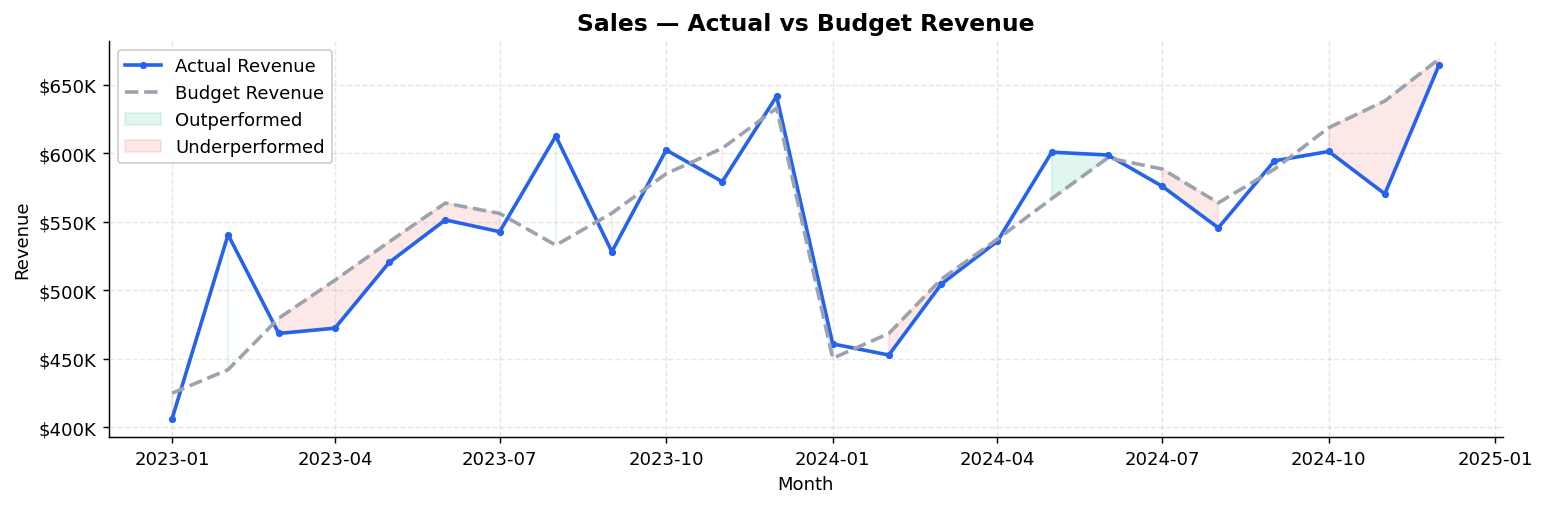

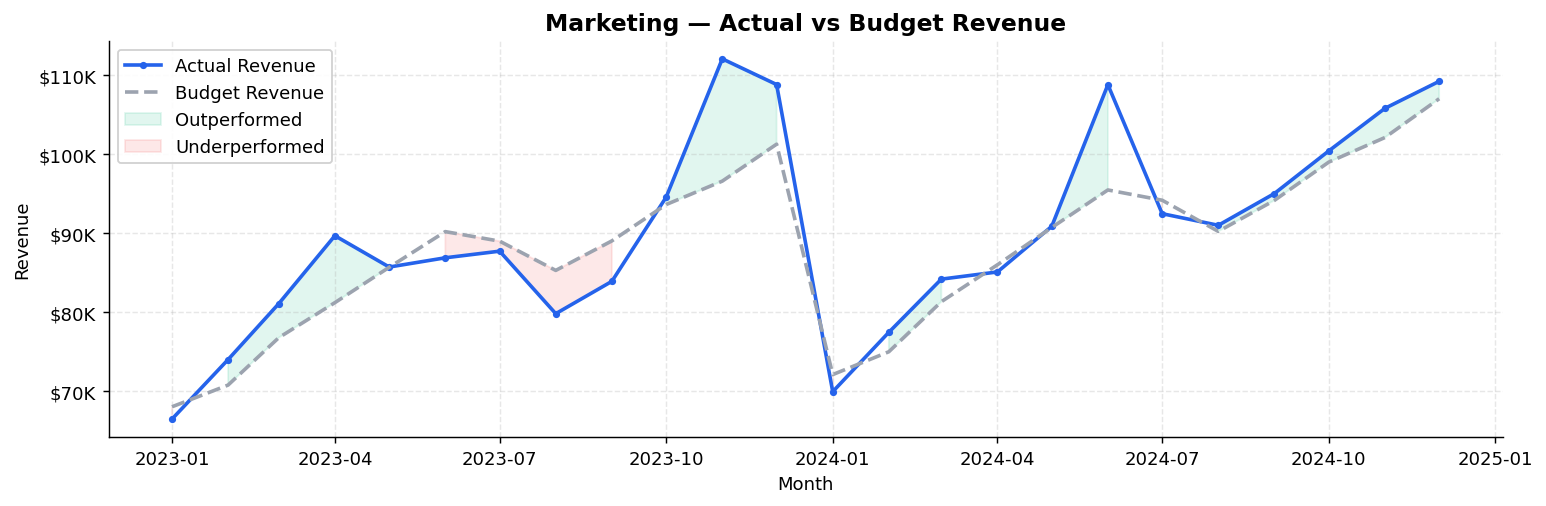

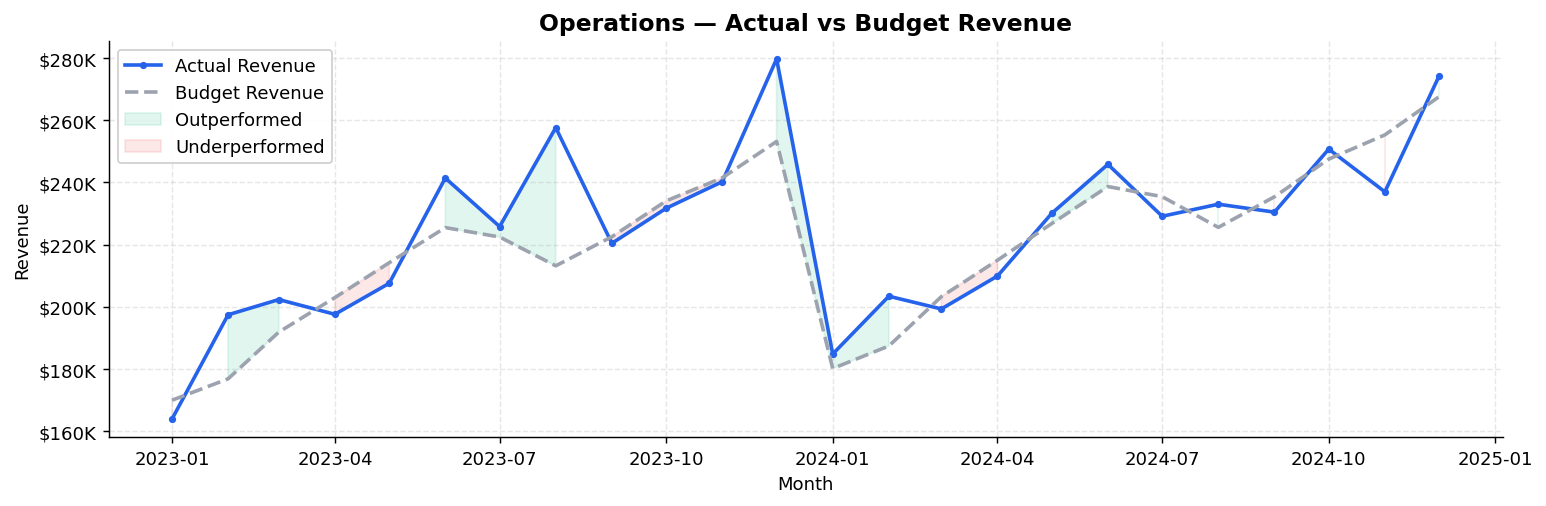

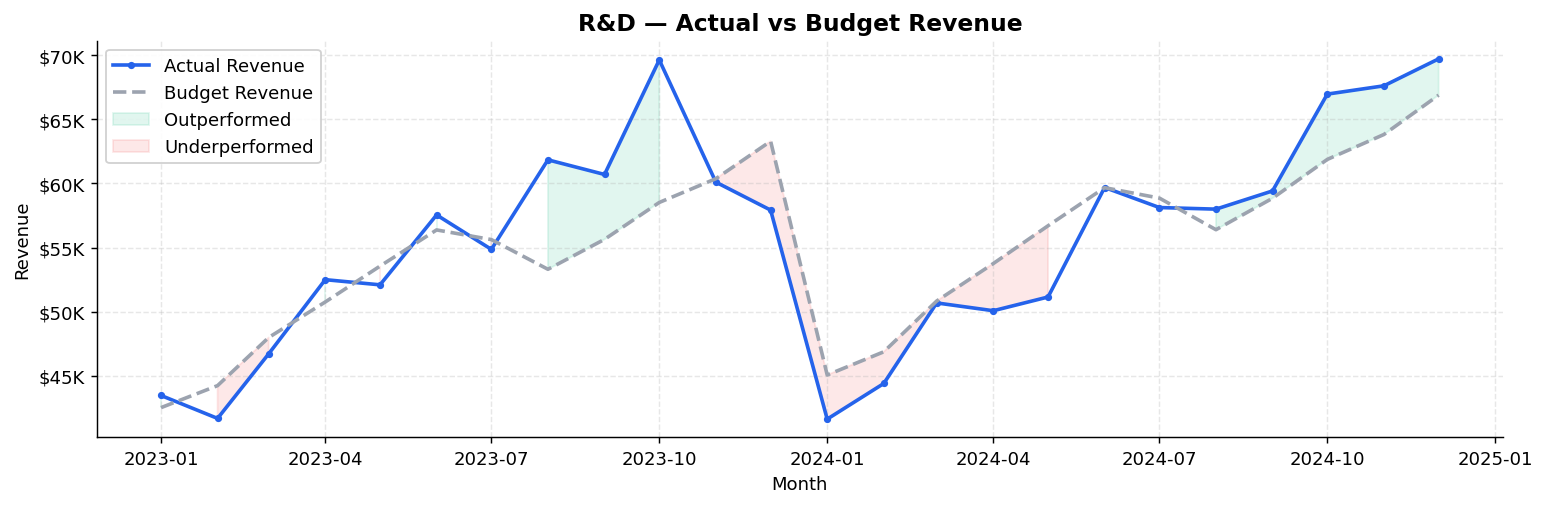

In [7]:
for department in df["department"].unique():
    actuals = df[(df["is_actual"]) & (df["department"] == department)].sort_values("date")
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(actuals["date"], actuals["actual_revenue"],  color=PALETTE["actual"],  lw=2, label="Actual Revenue",  marker="o", markersize=3)
    ax.plot(actuals["date"], actuals["budget_revenue"],  color=PALETTE["budget"],  lw=2, label="Budget Revenue",  linestyle="--")
    ax.fill_between(actuals["date"], actuals["actual_revenue"], actuals["budget_revenue"],
        where=actuals["actual_revenue"] >= actuals["budget_revenue"], alpha=0.12, color=PALETTE["positive"], label="Outperformed")
    ax.fill_between(actuals["date"], actuals["actual_revenue"], actuals["budget_revenue"],
        where=actuals["actual_revenue"] <  actuals["budget_revenue"], alpha=0.12, color=PALETTE["negative"], label="Underperformed")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_millions))
    ax.set_title(f"{department} — Actual vs Budget Revenue", fontsize=13, fontweight="bold")
    ax.set_xlabel("Month"); ax.set_ylabel("Revenue"); ax.legend(framealpha=0.9)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"01_actual_vs_budget_{department.lower()}.png")
    plt.show()


### Chart 2 — Waterfall Profit Variance

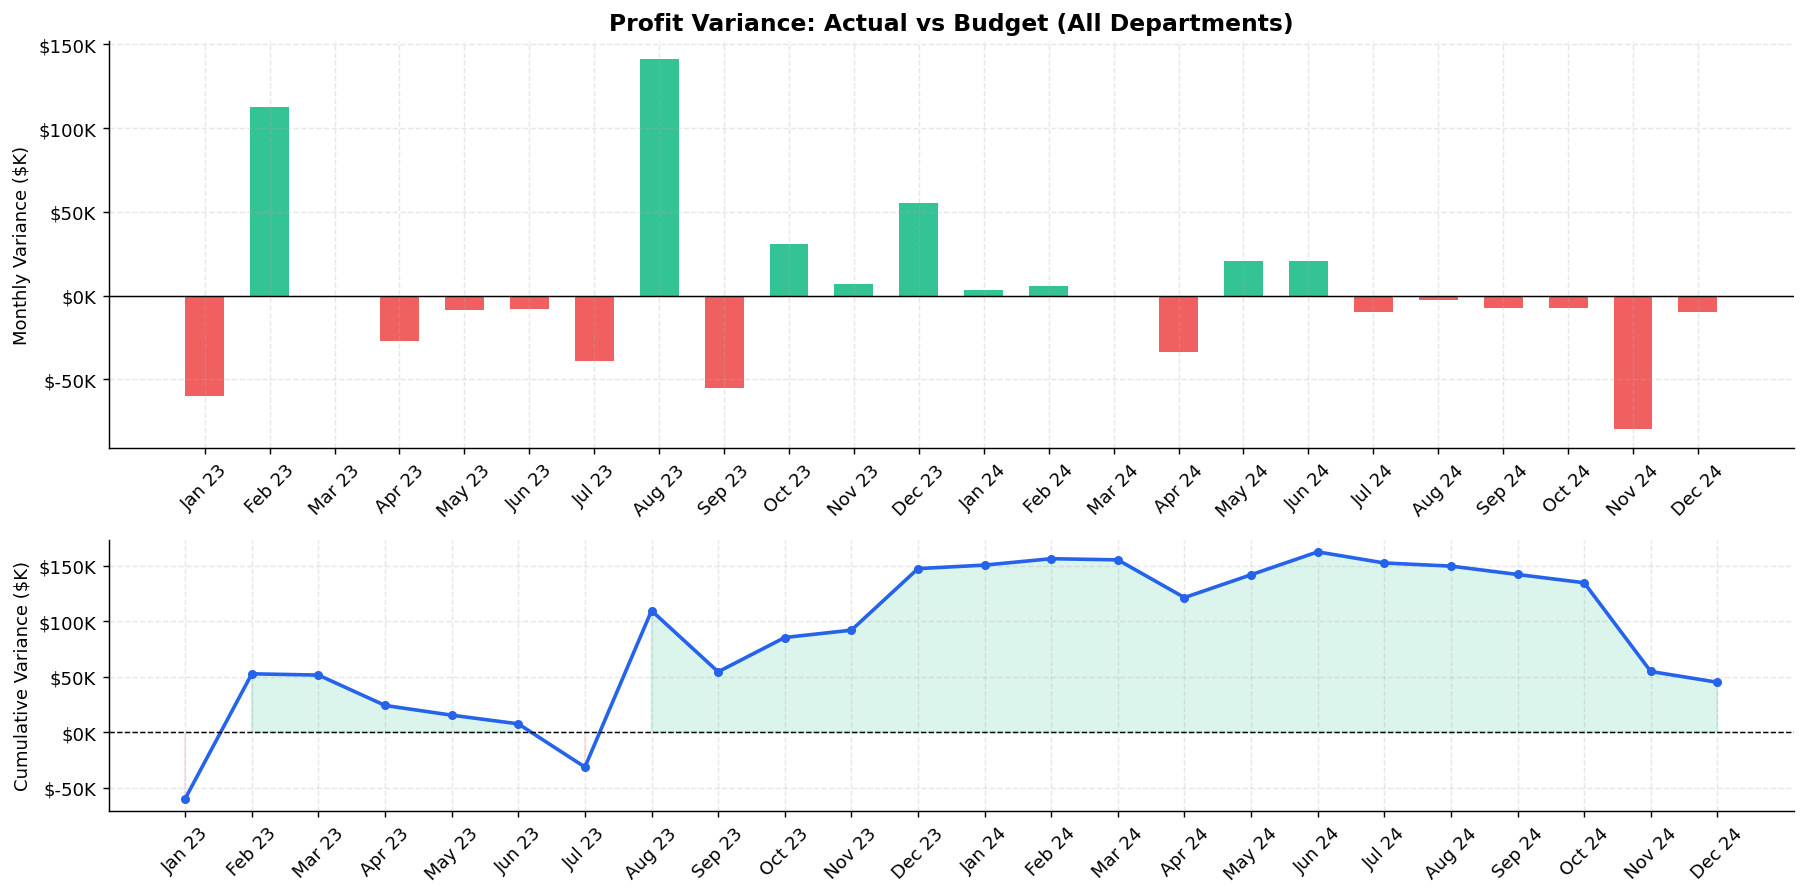

In [8]:
monthly = (
    variance_df.groupby("date")["profit_variance_abs"].sum()
    .reset_index().sort_values("date")
)
monthly["cumulative"] = monthly["profit_variance_abs"].cumsum()
monthly["color"]      = monthly["profit_variance_abs"].apply(lambda x: PALETTE["positive"] if x >= 0 else PALETTE["negative"])
monthly["label"]      = monthly["date"].dt.strftime("%b %y")

fig, axes = plt.subplots(2, 1, figsize=(14, 7), gridspec_kw={"height_ratios": [1.5, 1]})

ax = axes[0]
ax.bar(monthly["label"], monthly["profit_variance_abs"] / 1_000, color=monthly["color"], width=0.6, alpha=0.85)
ax.axhline(0, color="black", lw=0.8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}K"))
ax.set_title("Profit Variance: Actual vs Budget (All Departments)", fontsize=13, fontweight="bold")
ax.set_ylabel("Monthly Variance ($K)"); ax.tick_params(axis="x", rotation=45)

ax2 = axes[1]
ax2.plot(monthly["label"], monthly["cumulative"] / 1_000, color=PALETTE["actual"], lw=2, marker="o", markersize=4)
ax2.axhline(0, color="black", lw=0.8, linestyle="--")
ax2.fill_between(monthly["label"], monthly["cumulative"] / 1_000, 0,
    where=monthly["cumulative"] >= 0, alpha=0.15, color=PALETTE["positive"])
ax2.fill_between(monthly["label"], monthly["cumulative"] / 1_000, 0,
    where=monthly["cumulative"] <  0, alpha=0.15, color=PALETTE["negative"])
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"${x:.0f}K"))
ax2.set_ylabel("Cumulative Variance ($K)"); ax2.tick_params(axis="x", rotation=45)

fig.tight_layout()
fig.savefig(OUTPUT_DIR / "02_waterfall_profit_variance.png")
plt.show()


### Chart 3 — Cost Variance Heatmap

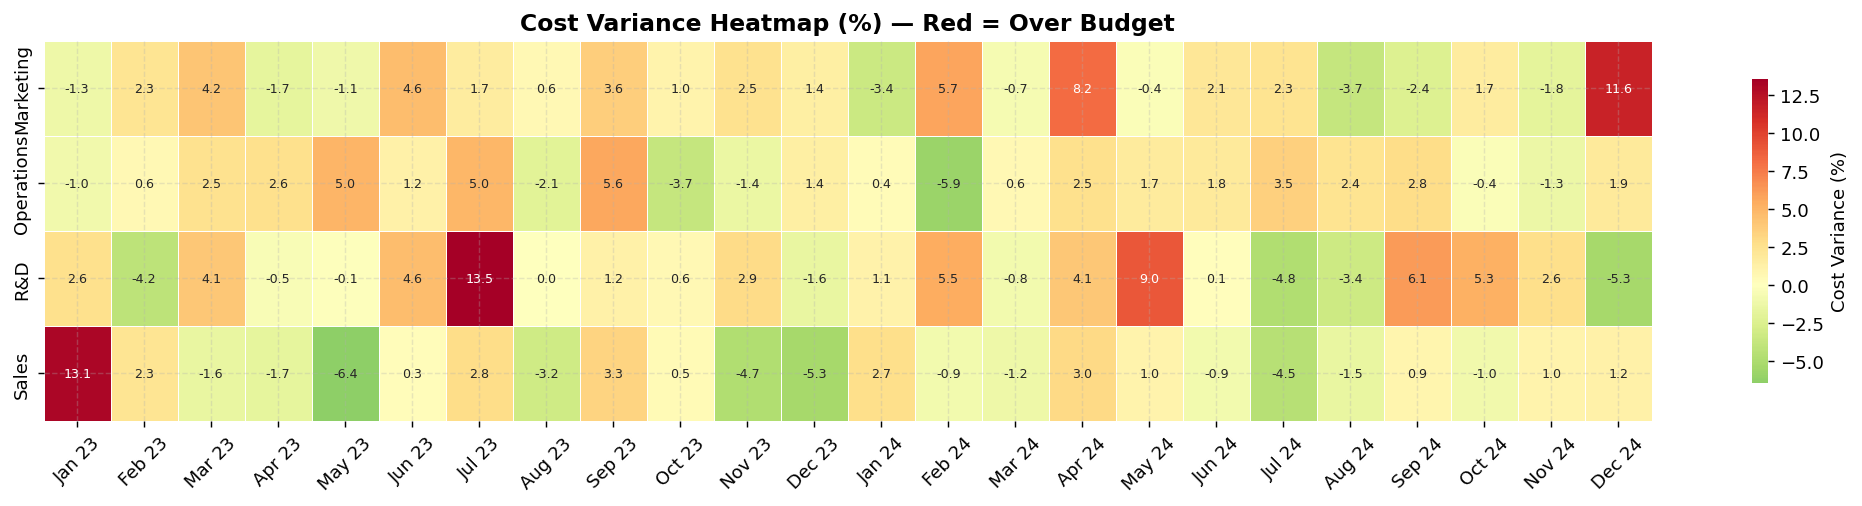

In [9]:
pivot = variance_df.pivot_table(
    index="department",
    columns=variance_df["date"].dt.strftime("%b %y"),
    values="cost_variance_pct",
    aggfunc="mean",
)
all_months = variance_df["date"].dt.strftime("%b %y").unique()
pivot = pivot.reindex(columns=[m for m in all_months if m in pivot.columns])

fig, ax = plt.subplots(figsize=(16, 4))
sns.heatmap(pivot * 100, ax=ax, cmap="RdYlGn_r", center=0,
    annot=True, fmt=".1f", annot_kws={"size": 7}, linewidths=0.4,
    cbar_kws={"label": "Cost Variance (%)", "shrink": 0.8})
ax.set_title("Cost Variance Heatmap (%) — Red = Over Budget", fontsize=13, fontweight="bold")
ax.set_xlabel(""); ax.set_ylabel(""); ax.tick_params(axis="x", rotation=45)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "03_cost_variance_heatmap.png")
plt.show()


### Chart 4 — Revenue Forecast vs Actuals vs Budget (by Department)

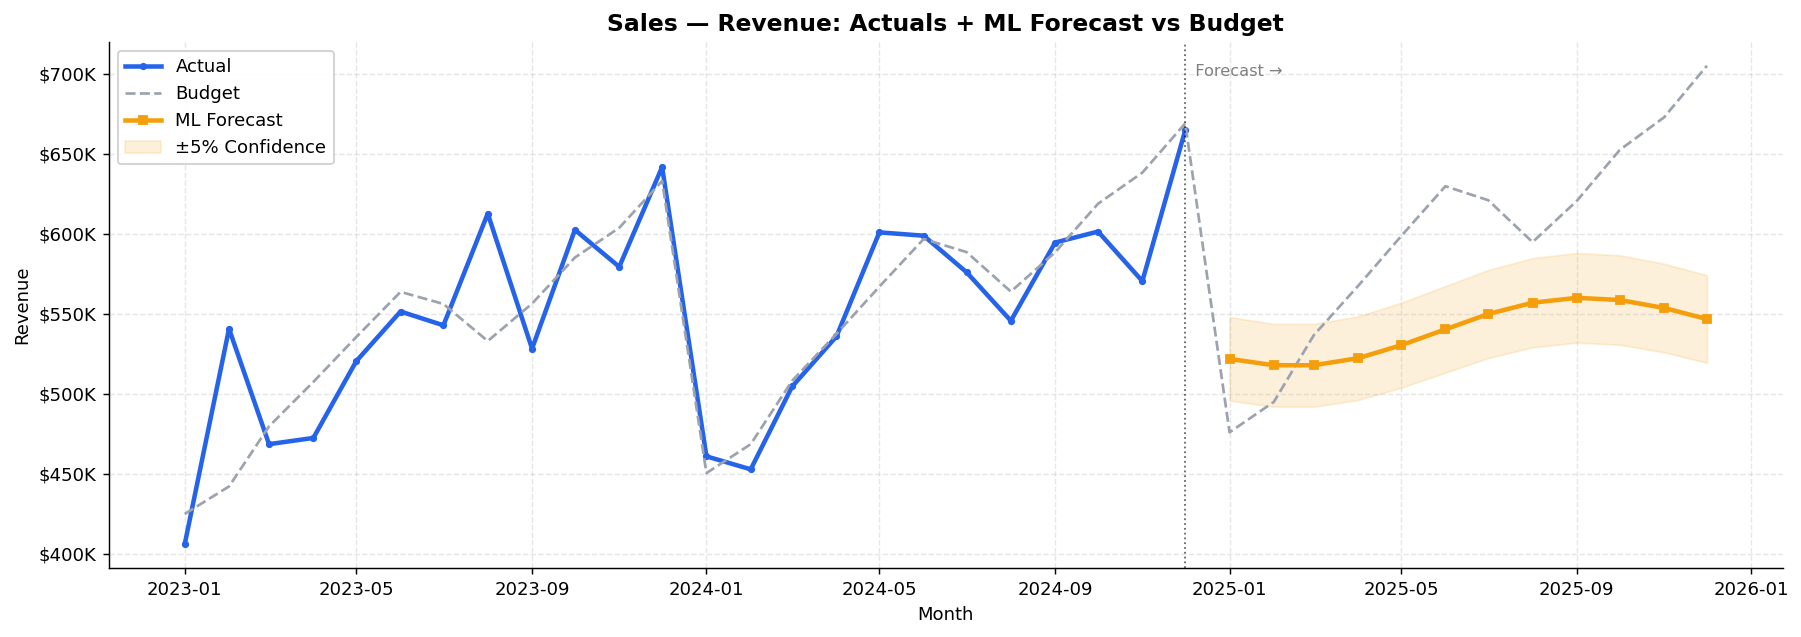

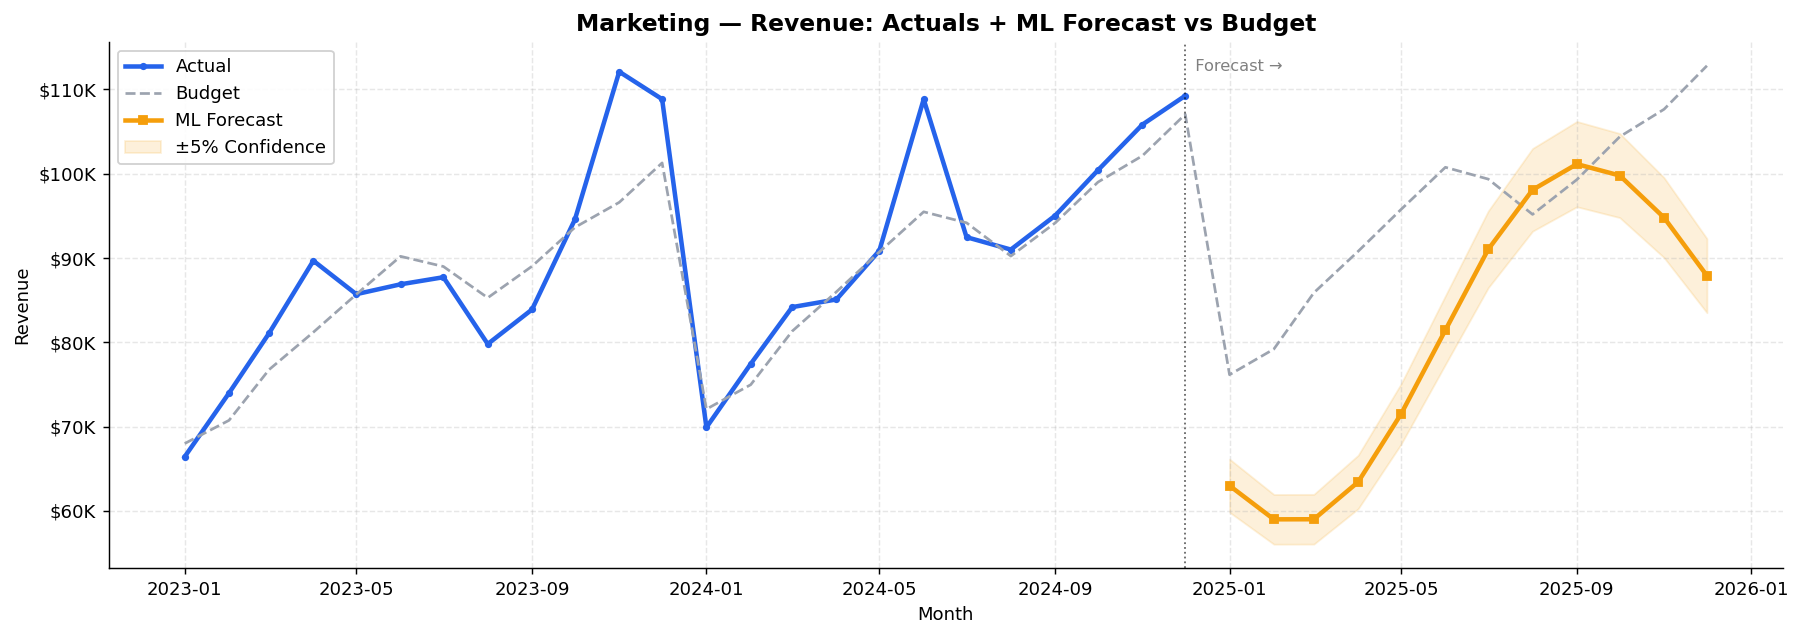

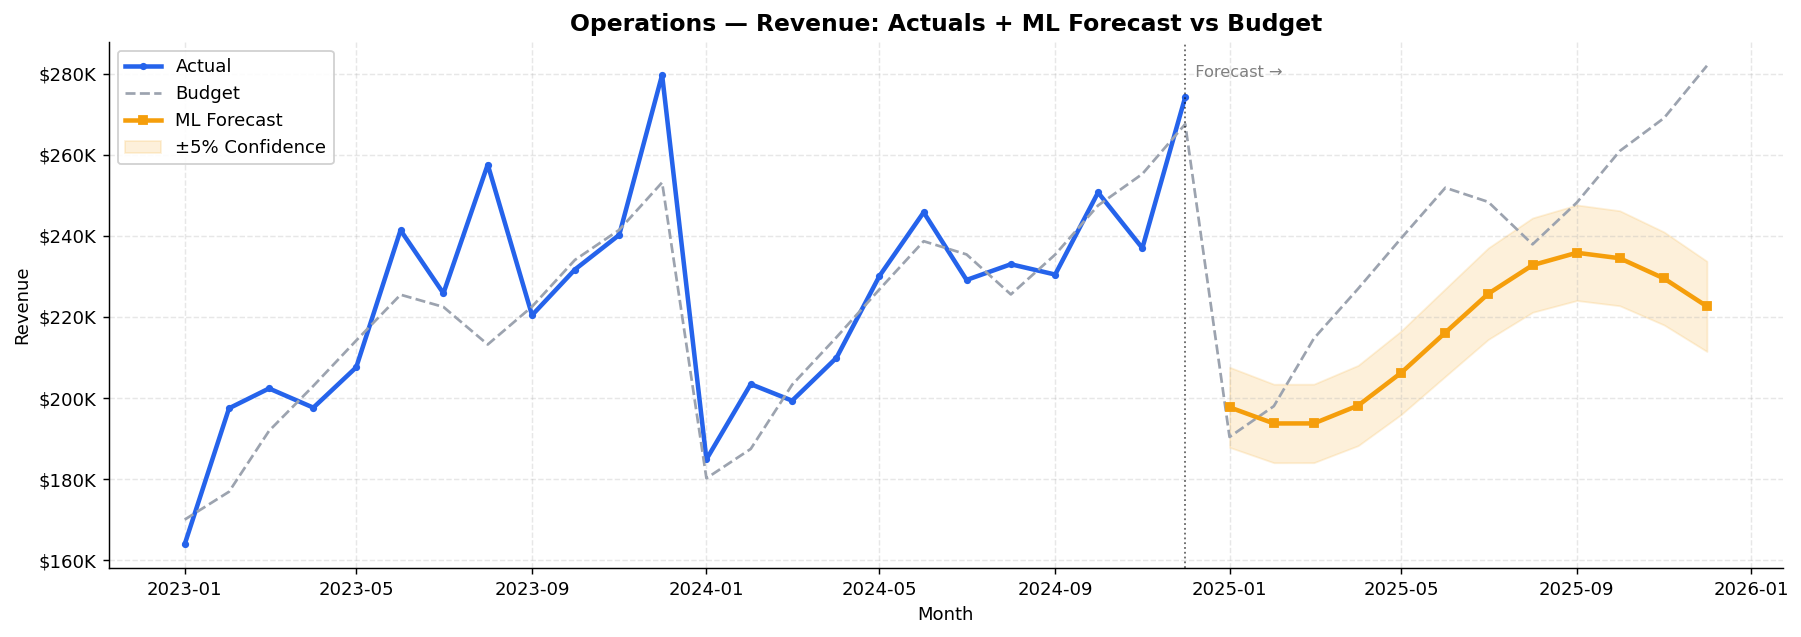

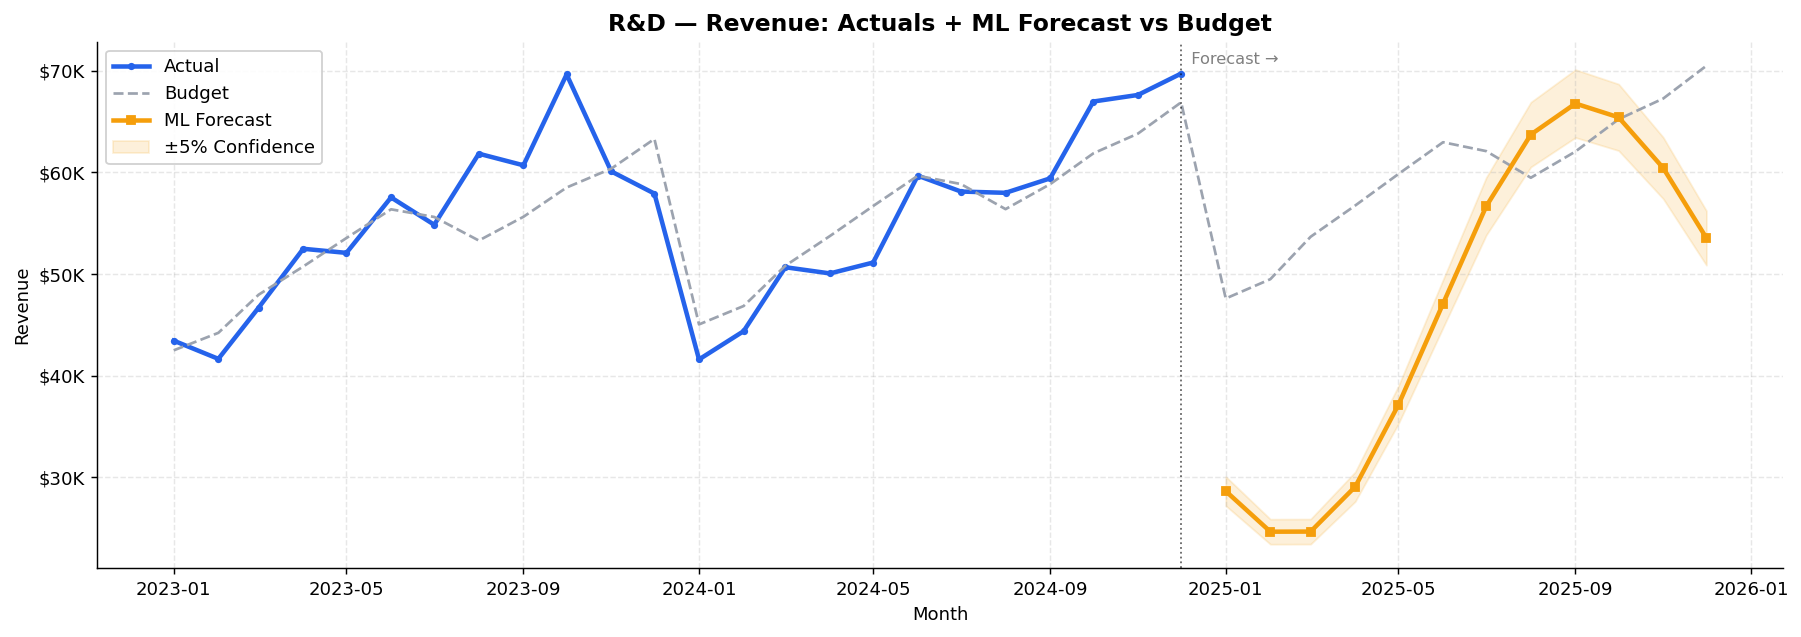

In [10]:
for department in df["department"].unique():
    actuals  = df[(df["is_actual"]) & (df["department"] == department)].sort_values("date")
    budget   = df[df["department"] == department].sort_values("date")
    forecast = forecast_df[forecast_df["department"] == department].sort_values("date")

    fig, ax = plt.subplots(figsize=(14, 5))
    ax.plot(actuals["date"],  actuals["actual_revenue"],    color=PALETTE["actual"],   lw=2.5, label="Actual",     marker="o", markersize=3)
    ax.plot(budget["date"],   budget["budget_revenue"],     color=PALETTE["budget"],   lw=1.5, label="Budget",     linestyle="--")
    ax.plot(forecast["date"], forecast["forecast_revenue"], color=PALETTE["forecast"], lw=2.5, label="ML Forecast",marker="s", markersize=4)
    ax.fill_between(forecast["date"],
        forecast["forecast_revenue"] * 0.95,
        forecast["forecast_revenue"] * 1.05,
        color=PALETTE["forecast"], alpha=0.15, label="±5% Confidence")
    split = actuals["date"].max()
    ax.axvline(split, color="black", lw=1, linestyle=":", alpha=0.6)
    ax.text(split, ax.get_ylim()[1] * 0.97, "  Forecast →", fontsize=9, color="gray")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(fmt_millions))
    ax.set_title(f"{department} — Revenue: Actuals + ML Forecast vs Budget", fontsize=13, fontweight="bold")
    ax.set_xlabel("Month"); ax.set_ylabel("Revenue"); ax.legend(framealpha=0.9)
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"04_forecast_{department.lower()}.png")
    plt.show()


### Chart 5 — Department KPI Summary

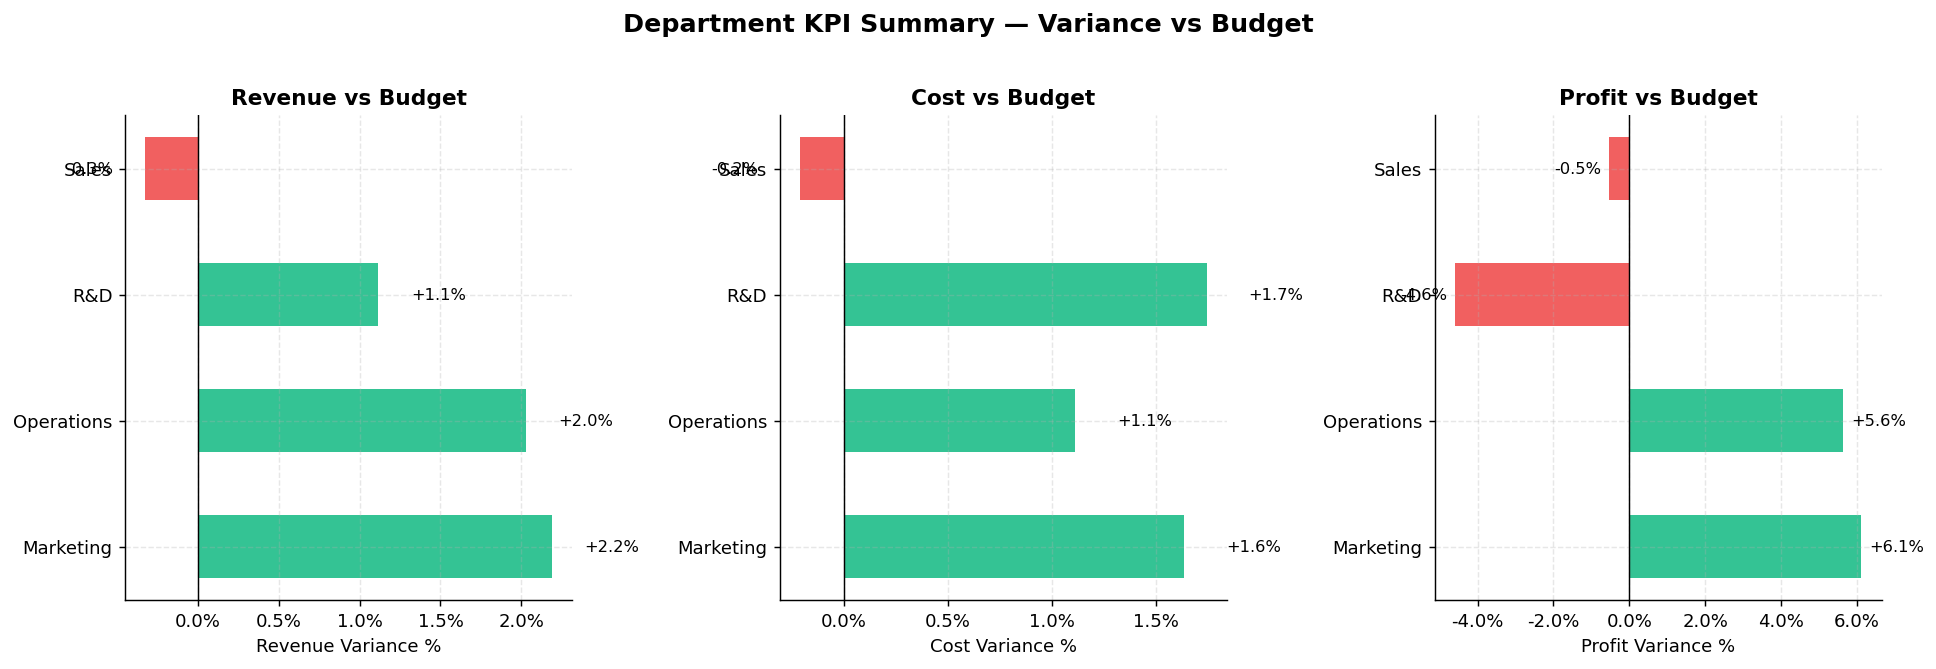

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
metrics = [
    ("rev_variance_pct",    "Revenue Variance %",  "Revenue vs Budget"),
    ("cost_variance_pct",   "Cost Variance %",     "Cost vs Budget"),
    ("profit_variance_pct", "Profit Variance %",   "Profit vs Budget"),
]
for ax, (col, ylabel, title) in zip(axes, metrics):
    vals   = dept_summary[col] * 100
    colors = [PALETTE["positive"] if v >= 0 else PALETTE["negative"] for v in vals]
    bars   = ax.barh(dept_summary["department"], vals, color=colors, alpha=0.85, height=0.5)
    ax.axvline(0, color="black", lw=0.8)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.1f}%"))
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.set_xlabel(ylabel)
    for bar, val in zip(bars, vals):
        ax.text(val + (0.2 if val >= 0 else -0.2), bar.get_y() + bar.get_height() / 2,
            f"{val:+.1f}%", va="center", ha="left" if val >= 0 else "right", fontsize=9)

fig.suptitle("Department KPI Summary — Variance vs Budget", fontsize=14, fontweight="bold", y=1.02)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / "05_department_kpi_summary.png", bbox_inches="tight")
plt.show()


## 6. Output Summary

In [12]:
print("All outputs saved to ./output/")
for f in sorted(OUTPUT_DIR.iterdir()):
    size = f.stat().st_size / 1024
    print(f"  {f.name:<45} ({size:.1f} KB)")


All outputs saved to ./output/
  01_actual_vs_budget_marketing.png             (102.1 KB)
  01_actual_vs_budget_operations.png            (110.8 KB)
  01_actual_vs_budget_r&d.png                   (104.5 KB)
  01_actual_vs_budget_sales.png                 (107.7 KB)
  02_waterfall_profit_variance.png              (162.1 KB)
  03_cost_variance_heatmap.png                  (151.0 KB)
  04_forecast_marketing.png                     (145.8 KB)
  04_forecast_operations.png                    (151.7 KB)
  04_forecast_r&d.png                           (135.1 KB)
  04_forecast_sales.png                         (141.1 KB)
  05_department_kpi_summary.png                 (81.8 KB)
  financial_data.csv                            (12.9 KB)
  forecast_output.csv                           (6.0 KB)
  variance_summary.csv                          (1.1 KB)
